In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%pip install -U scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 2.1 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.4 MB 1.8 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.4 MB 1.8 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.4 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.4 MB 1.3 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.4 MB 1.5 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.4 MB 1.5 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.4 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.4 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.4 MB 1.3 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.4 MB 1.1 MB/s eta 0:00:05
   ------------- ---------

In [2]:
!pip install pdfplumber

  Using cached pdfplumber-0.11.10-py3-none-any.whl.metadata (43 kB)
  Using cached pdfminer_six-20260107-py3-none-any.whl.metadata (4.3 kB)
  Using cached pypdfium2-5.13.0-py3-none-win_amd64.whl.metadata (67 kB)
Using cached pdfplumber-0.11.10-py3-none-any.whl (60 kB)
Using cached pdfminer_six-20260107-py3-none-any.whl (6.6 MB)
   ---------------------------------------- 0.0/3.9 MB ? eta -:--:--
   -- ------------------------------------- 0.3/3.9 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/3.9 MB 1.3 MB/s eta 0:00:03
   -------- ------------------------------- 0.8/3.9 MB 1.6 MB/s eta 0:00:02
   ------------- -------------------------- 1.3/3.9 MB 1.6 MB/s eta 0:00:02
   ---------------- ----------------------- 1.6/3.9 MB 1.5 MB/s eta 0:00:02
   ------------------ --------------------- 1.8/3.9 MB 1.5 MB/s eta 0:00:02
   --------------------- ------------------ 2.1/3.9 MB 1.5 MB/s eta 0:00:02
   ------------------------ --------------- 2.4/3.9 MB 1.5 MB/s eta 0:00:02



Student Performance Dataset:
    Study_Hours  Attendance  Previous_Score  Assignments  Sleep_Hours  \
0             2          60              45            4            5   
1             3          65              50            5            6   
2             4          70              55            6            6   
3             5          75              60            7            7   
4             6          80              65            8            7   
5             7          85              70            9            8   
6             8          90              75           10            8   
7             2          55              40            3            5   
8             3          68              48            5            6   
9             4          72              54            6            6   
10            5          78              62            7            7   
11            6          82              68            8            7   
12            7      

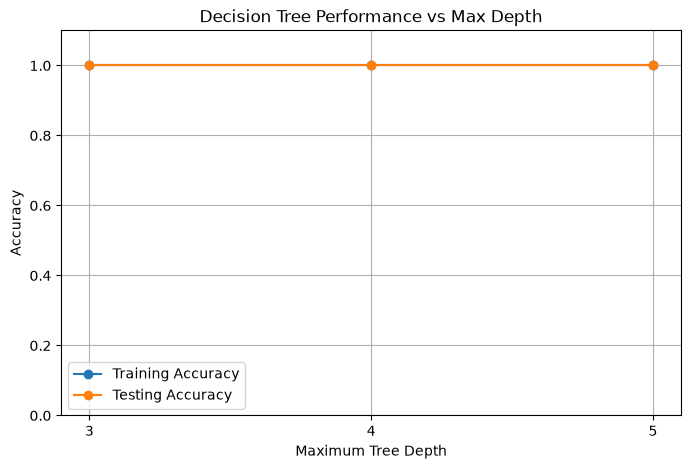

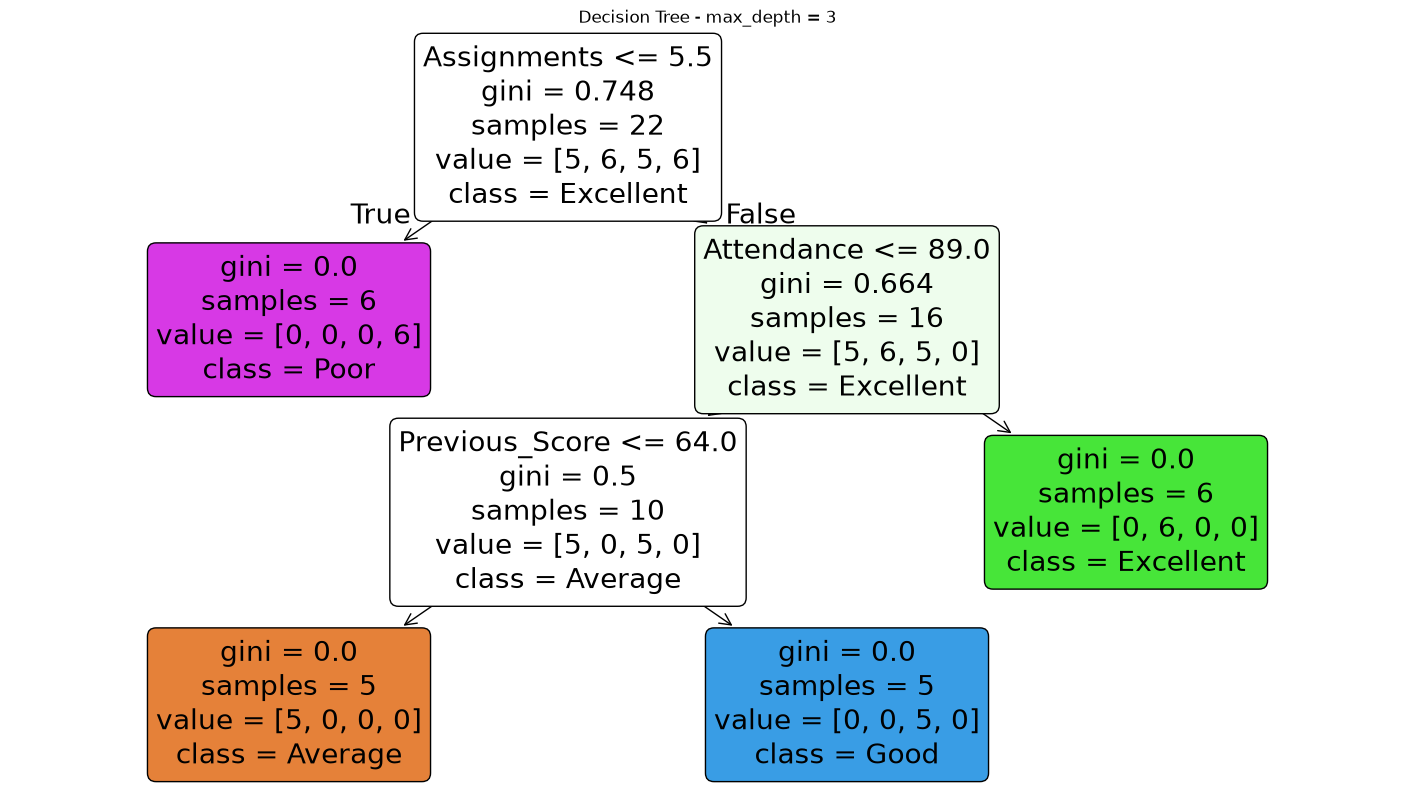

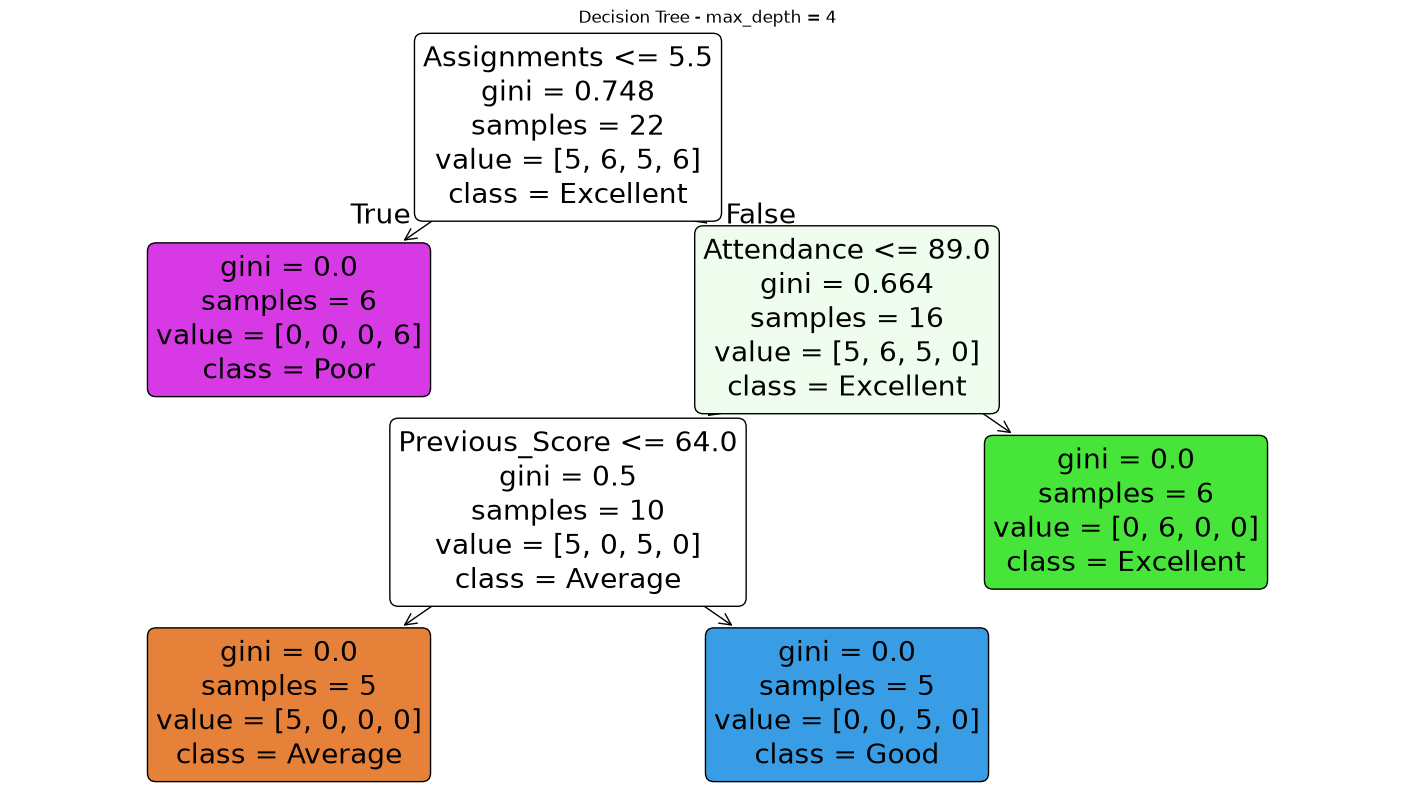

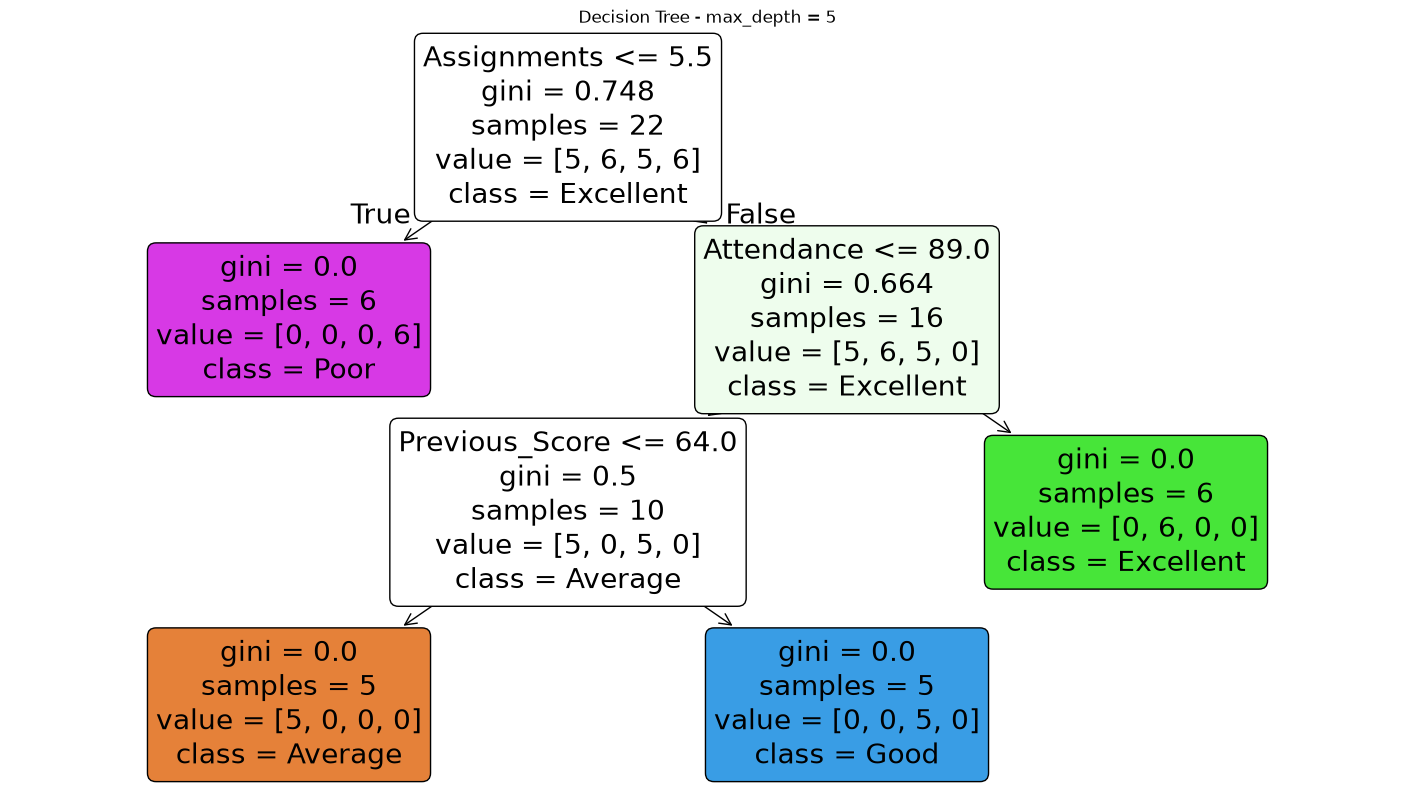


========== NEW STUDENT PREDICTION ==========
Max Depth 3: Good
Max Depth 4: Good
Max Depth 5: Good


In [3]:
# Student Performance Prediction using Decision Tree
# Comparing max_depth = 3, 4, 5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ---------------------------------------------------------
# 1. Create Student Performance Dataset
# ---------------------------------------------------------

data = {
    "Study_Hours": [
        2, 3, 4, 5, 6, 7, 8, 2, 3, 4,
        5, 6, 7, 8, 9, 1, 2, 4, 6, 8,
        3, 5, 7, 9, 10, 2, 4, 6, 8, 10
    ],

    "Attendance": [
        60, 65, 70, 75, 80, 85, 90, 55, 68, 72,
        78, 82, 88, 92, 95, 50, 62, 74, 86, 94,
        64, 76, 89, 96, 98, 58, 71, 84, 91, 97
    ],

    "Previous_Score": [
        45, 50, 55, 60, 65, 70, 75, 40, 48, 54,
        62, 68, 73, 80, 85, 35, 44, 58, 67, 82,
        49, 63, 77, 88, 92, 42, 57, 69, 81, 95
    ],

    "Assignments": [
        4, 5, 6, 7, 8, 9, 10, 3, 5, 6,
        7, 8, 9, 10, 10, 2, 4, 6, 8, 10,
        5, 7, 9, 10, 10, 3, 6, 8, 9, 10
    ],

    "Sleep_Hours": [
        5, 6, 6, 7, 7, 8, 8, 5, 6, 6,
        7, 7, 8, 8, 9, 5, 6, 6, 7, 8,
        6, 7, 8, 9, 9, 5, 6, 7, 8, 9
    ],

    "Performance": [
        "Poor", "Poor", "Average", "Average", "Good",
        "Good", "Excellent", "Poor", "Poor", "Average",
        "Average", "Good", "Good", "Excellent", "Excellent",
        "Poor", "Poor", "Average", "Good", "Excellent",
        "Poor", "Average", "Good", "Excellent", "Excellent",
        "Poor", "Average", "Good", "Excellent", "Excellent"
    ]
}

df = pd.DataFrame(data)

print("\nStudent Performance Dataset:")
print(df)


# ---------------------------------------------------------
# 2. Separate Features and Target
# ---------------------------------------------------------

X = df[
    [
        "Study_Hours",
        "Attendance",
        "Previous_Score",
        "Assignments",
        "Sleep_Hours"
    ]
]

y = df["Performance"]


# ---------------------------------------------------------
# 3. Split Dataset into Training and Testing
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# 4. Train Decision Trees with Different Depths
# ---------------------------------------------------------

depths = [3, 4, 5]

results = []

models = {}

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Max Depth": depth,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

    models[depth] = model

    print("\n--------------------------------------")
    print("Decision Tree with max_depth =", depth)
    print("--------------------------------------")

    print("Training Accuracy:",
          round(train_accuracy * 100, 2), "%")

    print("Testing Accuracy:",
          round(test_accuracy * 100, 2), "%")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


# ---------------------------------------------------------
# 5. Comparative Analysis
# ---------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n\n========== COMPARATIVE ANALYSIS ==========")
print(results_df.to_string(index=False))


# ---------------------------------------------------------
# 6. Plot Accuracy Comparison
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Max Depth"],
    results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    results_df["Max Depth"],
    results_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance vs Max Depth")
plt.xticks([3, 4, 5])
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()

plt.show()


# ---------------------------------------------------------
# 7. Display Decision Tree for Each Depth
# ---------------------------------------------------------

for depth in depths:

    plt.figure(figsize=(18, 10))

    plot_tree(
        models[depth],
        feature_names=X.columns,
        class_names=models[depth].classes_,
        filled=True,
        rounded=True
    )

    plt.title(
        f"Decision Tree - max_depth = {depth}"
    )

    plt.show()


# ---------------------------------------------------------
# 8. Predict Performance of a New Student
# ---------------------------------------------------------

new_student = pd.DataFrame({
    "Study_Hours": [7],
    "Attendance": [88],
    "Previous_Score": [75],
    "Assignments": [9],
    "Sleep_Hours": [8]
})


print("\n========== NEW STUDENT PREDICTION ==========")

for depth in depths:

    prediction = models[depth].predict(new_student)

    print(
        f"Max Depth {depth}: "
        f"{prediction[0]}"
    )

Electronics Industry Dataset
--------------------------------
    Temperature_C  Power_Consumption_W
0              20                   48
1              22                   50
2              24                   52
3              26                   54
4              28                   57
5              30                   59
6              32                   61
7              34                   64
8              36                   66
9              38                   69
10             40                   71
11             42                   74
12             44                   76
13             46                   79
14             48                   81
15             50                   84
16             52                   87
17             54                   89
18             56                   92
19             58                   95

Linear Regression Model
--------------------------------
Slope: 1.2609711958980545
Intercept: 21.09651636253959

Regre

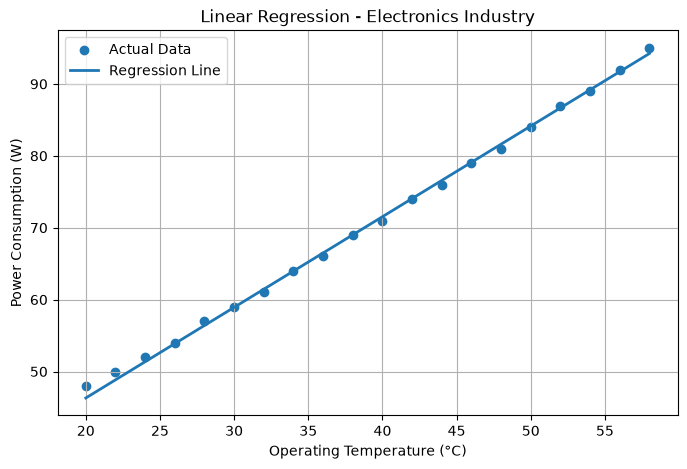


New Prediction
--------------------------------
Temperature: 45 °C
Predicted Power Consumption: 77.84 W


d:\AI Bootcamp\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [4]:
# Linear Regression Application in Electronics Industry
# Predicting Power Consumption based on Operating Temperature

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ---------------------------------------------------------
# 1. Create Electronics Industry Dataset
# ---------------------------------------------------------

data = {
    "Temperature_C": [
        20, 22, 24, 26, 28,
        30, 32, 34, 36, 38,
        40, 42, 44, 46, 48,
        50, 52, 54, 56, 58
    ],

    "Power_Consumption_W": [
        48, 50, 52, 54, 57,
        59, 61, 64, 66, 69,
        71, 74, 76, 79, 81,
        84, 87, 89, 92, 95
    ]
}

df = pd.DataFrame(data)


# ---------------------------------------------------------
# 2. Display Dataset
# ---------------------------------------------------------

print("Electronics Industry Dataset")
print("--------------------------------")
print(df)


# ---------------------------------------------------------
# 3. Define Input and Output
# ---------------------------------------------------------

X = df[["Temperature_C"]]
y = df["Power_Consumption_W"]


# ---------------------------------------------------------
# 4. Split Dataset into Training and Testing Data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ---------------------------------------------------------
# 5. Create and Train Linear Regression Model
# ---------------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)


# ---------------------------------------------------------
# 6. Make Predictions
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# 7. Display Model Parameters
# ---------------------------------------------------------

print("\nLinear Regression Model")
print("--------------------------------")

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print(
    "\nRegression Equation:"
)

print(
    f"Power Consumption = "
    f"{model.intercept_:.2f} + "
    f"({model.coef_[0]:.2f} × Temperature)"
)


# ---------------------------------------------------------
# 8. Model Evaluation
# ---------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("\nModel Performance")
print("--------------------------------")

print("Mean Absolute Error (MAE):", round(mae, 2))

print("Mean Squared Error (MSE):", round(mse, 2))

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

print("R² Score:", round(r2, 4))


# ---------------------------------------------------------
# 9. Compare Actual and Predicted Values
# ---------------------------------------------------------

comparison = pd.DataFrame({
    "Temperature": X_test["Temperature_C"].values,
    "Actual Power": y_test.values,
    "Predicted Power": y_pred
})

print("\nActual vs Predicted Power")
print("--------------------------------")
print(comparison.to_string(index=False))


# ---------------------------------------------------------
# 10. Visualize Linear Regression
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Operating Temperature (°C)")
plt.ylabel("Power Consumption (W)")
plt.title(
    "Linear Regression - Electronics Industry"
)

plt.legend()
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# 11. Predict Power Consumption for New Temperature
# ---------------------------------------------------------

new_temperature = np.array([[45]])

predicted_power = model.predict(new_temperature)


print("\nNew Prediction")
print("--------------------------------")

print(
    f"Temperature: {new_temperature[0][0]} °C"
)

print(
    f"Predicted Power Consumption: "
    f"{predicted_power[0]:.2f} W"
)

In [5]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


Student Dataset:
    Study_Hours  Exam_Score
0             1          35
1             2          40
2             2          42
3             3          45
4             3          48
5             4          52
6             5          55
7             6          60
8             6          62
9             7          65
10            7          68
11            8          72
12            8          75
13            9          78
14           10          82
15           10          85
16           11          88
17           12          91
18           12          94
19           13          96


d:\AI Bootcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Dataset after Clustering:
    Study_Hours  Exam_Score  Cluster
0             1          35        1
1             2          40        1
2             2          42        1
3             3          45        1
4             3          48        1
5             4          52        1
6             5          55        1
7             6          60        2
8             6          62        2
9             7          65        2
10            7          68        2
11            8          72        2
12            8          75        2
13            9          78        2
14           10          82        0
15           10          85        0
16           11          88        0
17           12          91        0
18           12          94        0
19           13          96        0

Cluster Centers:
[[11.33333333 89.33333333]
 [ 2.85714286 45.28571429]
 [ 7.28571429 68.57142857]]


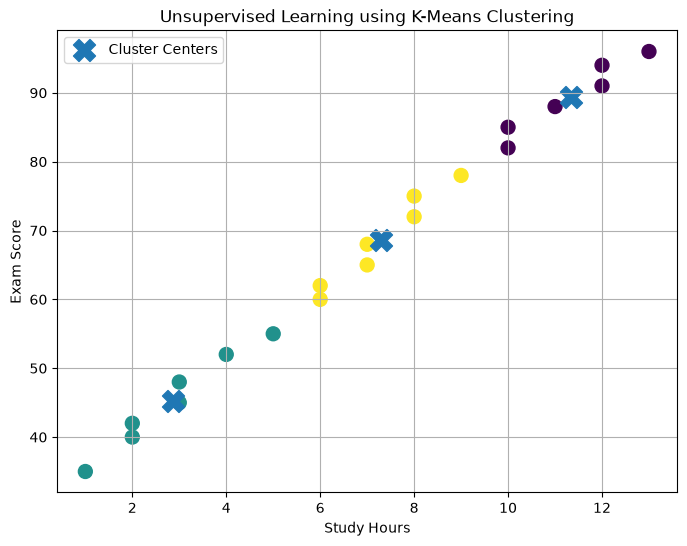

In [6]:
# Demonstration of Unsupervised Learning using K-Means Clustering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# ---------------------------------------------------
# 1. Create sample student dataset
# ---------------------------------------------------

data = {
    "Study_Hours": [1, 2, 2, 3, 3, 4, 5, 6, 6, 7,
                    7, 8, 8, 9, 10, 10, 11, 12, 12, 13],

    "Exam_Score": [35, 40, 42, 45, 48, 52, 55, 60, 62, 65,
                   68, 72, 75, 78, 82, 85, 88, 91, 94, 96]
}

df = pd.DataFrame(data)

print("Student Dataset:")
print(df)

# ---------------------------------------------------
# 2. Select features
# ---------------------------------------------------

X = df[["Study_Hours", "Exam_Score"]]

# ---------------------------------------------------
# 3. Create K-Means model
# ---------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train the unsupervised learning model
kmeans.fit(X)

# ---------------------------------------------------
# 4. Add cluster labels to dataset
# ---------------------------------------------------

df["Cluster"] = kmeans.labels_

print("\nDataset after Clustering:")
print(df)

# ---------------------------------------------------
# 5. Display cluster centers
# ---------------------------------------------------

print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# ---------------------------------------------------
# 6. Visualize the clusters
# ---------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Study_Hours"],
    df["Exam_Score"],
    c=df["Cluster"],
    s=100
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    label="Cluster Centers"
)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Unsupervised Learning using K-Means Clustering")
plt.legend()
plt.grid(True)

plt.show()